<a href="https://colab.research.google.com/github/OgunbanjoT/Lab2AI/blob/main/AI_Assignment9_Toyin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch

# Load the dataset directly via URL so you don't have to upload files manually
url = "https://raw.githubusercontent.com/kennedykwangari/Mall-Customer-Segmentation-Data/master/Mall_Customers.csv"
df = pd.read_csv(url)

# Display data preview
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# Data Preprocessing
# Drop CustomerID as it isn't a feature for clustering
X = df.drop(columns=['CustomerID'])

# One-hot encode the categorical 'Gender' column
X = pd.get_dummies(X, columns=['Gender'], drop_first=True)

# Standardize features so they have a mean of 0 and variance of 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data successfully preprocessed. Shape of data:", X_scaled.shape)

Data successfully preprocessed. Shape of data: (200, 4)


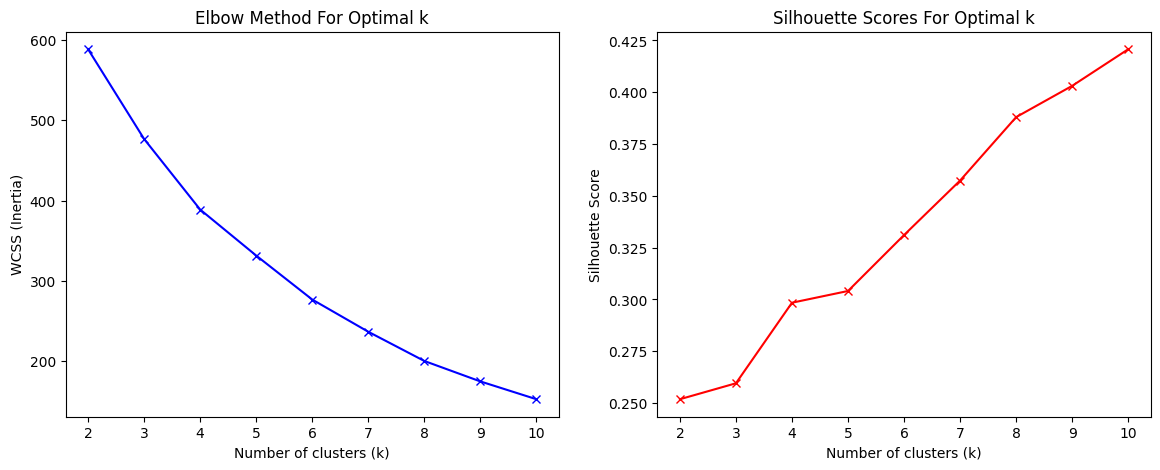

In [4]:
# K-Means & Elbow Method
wcss = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plotting the evaluation graphs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Curve
ax1.plot(K_range, wcss, 'bx-')
ax1.set_title('Elbow Method For Optimal k')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('WCSS (Inertia)')

# Silhouette Scores
ax2.plot(K_range, silhouette_scores, 'rx-')
ax2.set_title('Silhouette Scores For Optimal k')
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Silhouette Score')

plt.show()

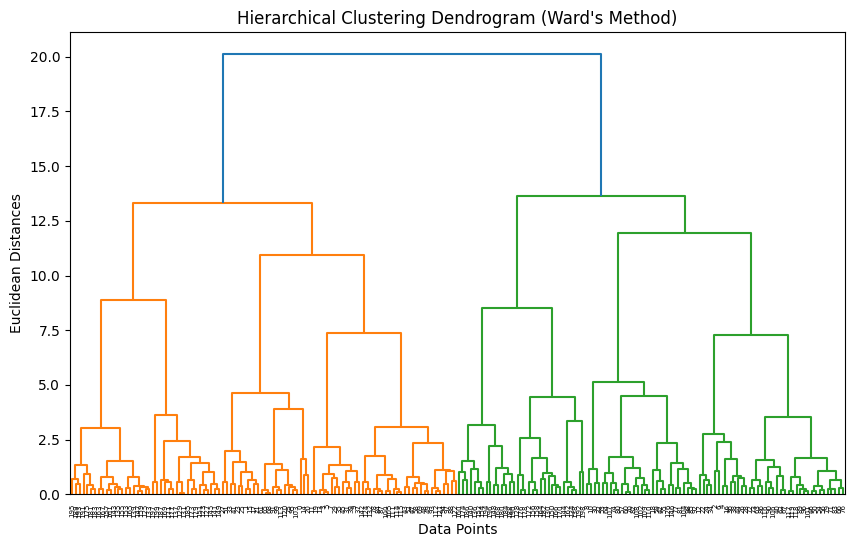

In [5]:
# Hierarchical Clustering Dendrogram
plt.figure(figsize=(10, 6))
plt.title("Hierarchical Clustering Dendrogram (Ward's Method)")
dend = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distances")
plt.show()

Final K-Means Silhouette Score for 5 clusters: 0.3041


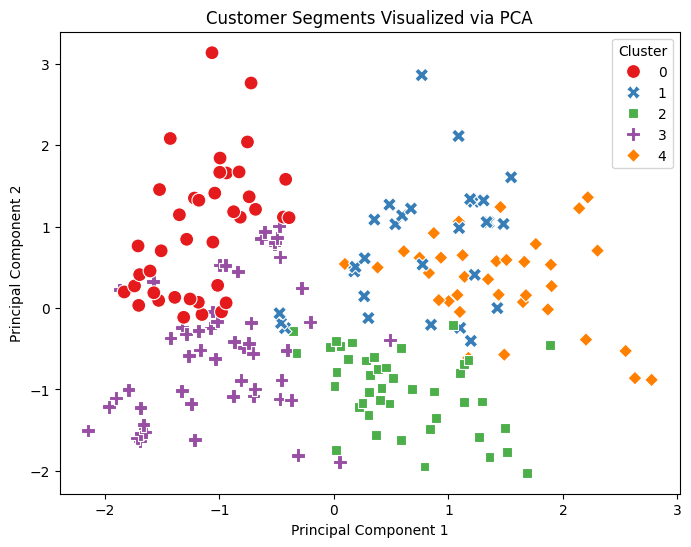

In [6]:
# PCA and Final Cluster Visualization
# Train final K-Means model
optimal_k = 5
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels = kmeans_final.fit_predict(X_scaled)

# Calculate Silhouette Score for final model
score = silhouette_score(X_scaled, labels)
print(f"Final K-Means Silhouette Score for {optimal_k} clusters: {score:.4f}")

# Dimensionality Reduction with PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create a clean plotting DataFrame
df_pca = pd.DataFrame(X_pca, columns=['Principal Component 1', 'Principal Component 2'])
df_pca['Cluster'] = labels

# Plot the 2D cluster map
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='Cluster', palette='Set1', data=df_pca, style='Cluster', s=100)
plt.title('Customer Segments Visualized via PCA')
plt.show()